#  Tutorial: Extracción de Datos Macroeconómicos
**VarPy — Toolbox for VAR Modeling in Python**

Este notebook muestra cómo usar el módulo de funciones de  `varpy_data` para descargar series económicas desde:
- 🏦 **BCRP** — Banco Central de Reserva del Perú
- 🌍 **World Bank** — Banco Mundial

### Frecuencias soportadas por `bcrp_fetch`

| Frecuencia  | Formato fecha_inicio / fecha_fin | Ejemplo            |
|-------------|----------------------------------|--------------------|
| Diaria      | `'YYYY-MM-DD'`                   | `'2010-01-01'`     |
| Mensual     | `'YYYY-MM'`                      | `'2010-01'`        |
| Trimestral  | `'YYYY-MM'`                      | `'2010-01'`        |
| Anual       | `'YYYY'`                         | `'2010'`           |


## Importaciones

In [1]:
import sys
import os
# Ajusta la ruta según donde tengas varpy_data.py
RUTA_FUNCIONES = os.path.abspath(os.path.join('..', 'funciones'))
sys.path.insert(0, RUTA_FUNCIONES)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from varpy_data import bcrp_fetch, bcrp_metadata_url, wb_fetch, wb_metadata_url, LATAM
plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


##  Parte 1: BCRP — Banco Central de Reserva del Perú
### ¿Cómo encontrar los códigos de las series?
Ejecuta la celda de abajo para acceder al catálogo de metadatos del BCRP.

In [2]:
bcrp_metadata_url()

📖 Catálogo de series BCRP: https://estadisticas.bcrp.gob.pe/estadisticas/series/ayuda/metadatos


'https://estadisticas.bcrp.gob.pe/estadisticas/series/ayuda/metadatos'


### Serie DIARIA: Tipo de Cambio

| Código | Serie |
|---|---|
| `PD04638PD` | Tipo de cambio bancario — venta (S/ por USD) |

**Formato de fecha:** `'YYYY-MM-DD'`

In [3]:
df_tc = bcrp_fetch(
    series       = ["PD04638PD"],
    fecha_inicio = "2010-01-01",
    fecha_fin    = "2025-12-31",
    nombres      = ["Tipo_Cambio"]
)
df_tc.tail()

✅ BCRP: 3978 observaciones | 2010-01-04 → 2025-12-31


,Tipo_Cambio
Fecha,
2025-12-23,3.367000
2025-12-24,3.365000
2025-12-29,3.367000
2025-12-30,3.364357
2025-12-31,3.363600


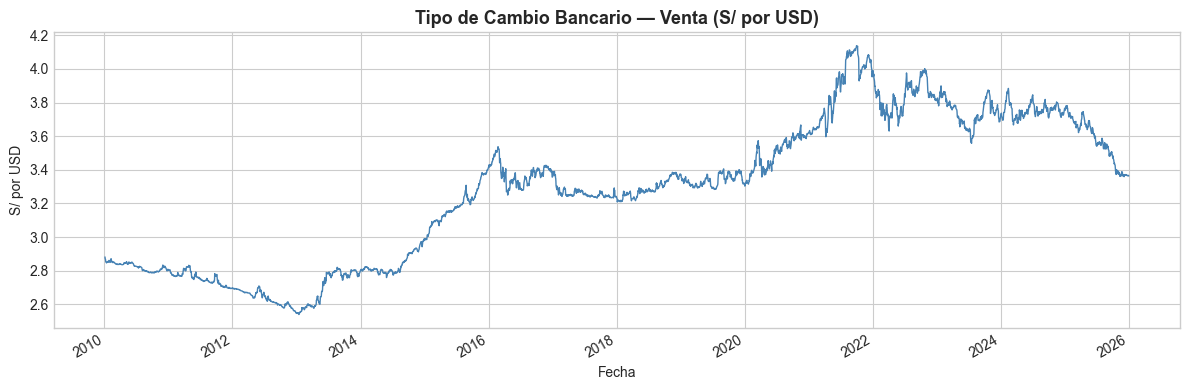

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
df_tc["Tipo_Cambio"].plot(ax=ax, color="steelblue", linewidth=1)
ax.set_title("Tipo de Cambio Bancario — Venta (S/ por USD)", fontsize=13, fontweight="bold")
ax.set_ylabel("S/ por USD")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

### Serie MENSUAL: IPC e Inflación

| Código | Serie |
|---|---|
| `PN01273PM` | IPC — Var. % 12 meses |
| `PN01277PM` | IPC sin Alimentos y Energía — Var. % 12 meses |
| `PN09819PM` | IPC Alimentos y Energía — Var. % 12 meses |

**Formato de fecha:** `'YYYY-MM'`

In [5]:
df_ipc = bcrp_fetch(
    series       = ["PN01273PM", "PN01277PM", "PN09819PM"],
    fecha_inicio = "2000-01",
    fecha_fin    = "2025-12",
    nombres      = ["IPC", "IPC_sin_alimentos_energia", "IPC_alimentos_energia"]
)
df_ipc.tail()

✅ BCRP: 312 observaciones | 2000-01-01 → 2025-12-01


,IPC,IPC_sin_alimentos_energia,IPC_alimentos_energia
Fecha,,,
2025-08-01,1.106331,1.751713,0.360091
2025-09-01,1.358393,1.811908,0.831380
2025-10-01,1.351775,1.772149,0.861662
2025-11-01,1.368613,1.765001,0.907315
2025-12-01,1.508800,1.830782,1.132966


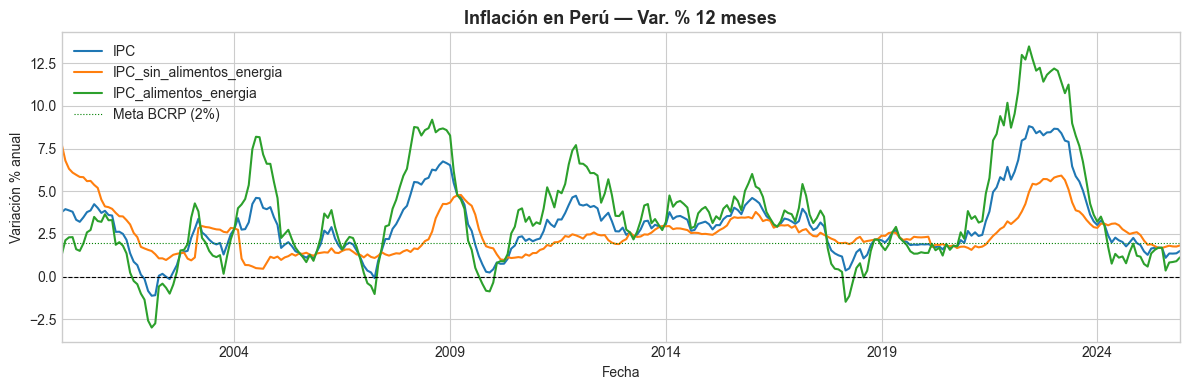

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
df_ipc.plot(ax=ax, linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axhline(2, color="green", linewidth=0.8, linestyle=":", label="Meta BCRP (2%)")
ax.set_title("Inflación en Perú — Var. % 12 meses", fontsize=13, fontweight="bold")
ax.set_ylabel("Variación % anual")
ax.legend()
plt.tight_layout()
plt.show()

# Extración de Data para nuestro VAR

Para nuestro var queremos usar estos datos especificos dando la logica del modelo puedes cambiar y buscar para poder almacenar tus datos

In [7]:
# ─────────────────────────────────────────────
# expec : Índice de expectativas de la economía a 3 meses (total)
# tasa  : Tasa de interés de referencia BCRP
# gpbi  : Variación del PBI real (var. % anual)
# gipx  : Crecimiento de terminos de intercambio (var. % anual t)
# ─────────────────────────────────────────────
df = bcrp_fetch(
    series       = ["PD38045AM", "PD04722MM", "PN01728AM", "PN38924BM"],
    fecha_inicio = "2004-01",
    fecha_fin    = "2025-01",
    nombres      = ["expec", "tasa", "gpbi", "gipx"]
)
df.tail()

✅ BCRP: 253 observaciones | 2004-01-01 → 2025-01-01


,expec,tasa,gpbi,gipx
Fecha,,,,
2024-09-01,5.25,51.771654,3.490532,3.490502
2024-10-01,5.25,51.737452,3.831103,-0.382965
2024-11-01,5.00,50.576923,4.382007,-0.220724
2024-12-01,5.00,50.000000,5.066222,2.152348
2025-01-01,4.75,52.592593,4.412621,-0.294208


In [8]:
# Exportar a Excel
#Lo vamos a almacenar en la carpeta data, que es donde el notebook 03 lo va a leer
df.to_excel("../data/DATA.xlsx", index=True)
print("Exportado correctamente como data/DATA.xlsx")

Exportado correctamente como data/DATA.xlsx


## Banco Mundial

In [9]:
# Puedes acceder al contenido de la metadata con:
wb_metadata_url()

📖 Catálogo World Bank: https://databank.worldbank.org/metadataglossary/all/series


'https://databank.worldbank.org/metadataglossary/all/series'

### Serie ANUAL: Crecimiento del PBI (Banco Mundial)
| Código | Serie |
|---|---|
| `NY.GDP.MKTP.KD.ZG` | Crecimiento del PIB (% anual) |
**Fuente:** Banco Mundial  
**Nota:** Usamos datos del Banco Mundial ya que las series trimestrales del BCRP tienen restricciones de acceso.

In [10]:
df_pbi = wb_fetch(
    paises     = ["PER"],
    indicadores= ["NY.GDP.MKTP.KD.ZG"],
    año_inicio = 2000,
    año_fin    = 2023,
    nombres    = {"NY.GDP.MKTP.KD.ZG": "PBI_crecimiento_pct"}
)
# Filtrar solo Perú y preparar datos
df_pbi = df_pbi[df_pbi['ISO3'] == 'PER'][['Año', 'PBI_crecimiento_pct']].set_index('Año')
df_pbi.tail(8)

✅ World Bank: 24 filas | 1 países | 2000 → 2023


,PBI_crecimiento_pct
Año,
2016,3.953319
2017,2.518835
2018,3.969351
2019,2.240632
2020,-10.933307
2021,13.362624
2022,2.809034
2023,-0.403242


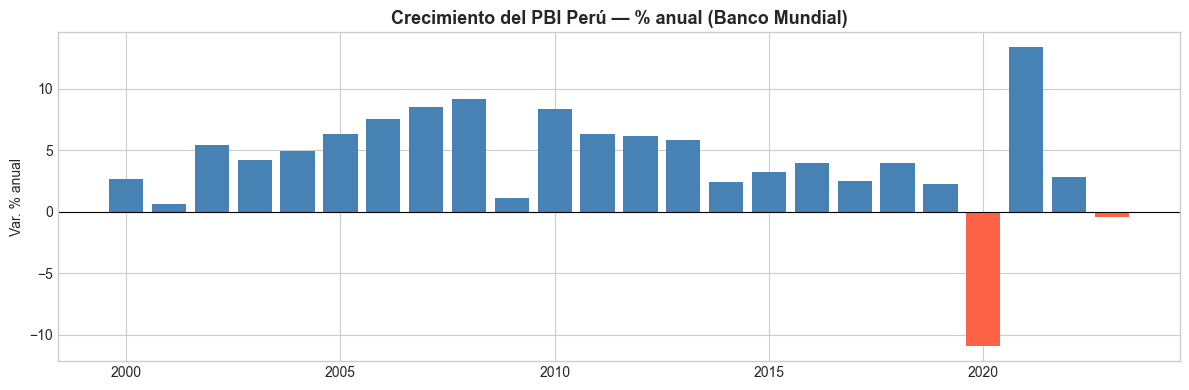

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df_pbi.index, df_pbi["PBI_crecimiento_pct"],
       color=["steelblue" if v >= 0 else "tomato" for v in df_pbi["PBI_crecimiento_pct"]])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Crecimiento del PBI Perú — % anual (Banco Mundial)", fontsize=13, fontweight="bold")
ax.set_ylabel("Var. % anual")
plt.tight_layout()
plt.show()


### Serie ANUAL: Población (Banco Mundial)

| Código | Serie |
|---|---|
| `SP.POP.TOTL` | Población total |

**Fuente:** Banco Mundial  
**Nota:** Usamos datos del Banco Mundial ya que las series anuales del BCRP tienen restricciones de acceso.

In [12]:
df_pop = wb_fetch(
    paises     = ["PER"],
    indicadores= ["SP.POP.TOTL"],
    año_inicio = 2000,
    año_fin    = 2023,
    nombres    = {"SP.POP.TOTL": "Poblacion_total"}
)
# Filtrar solo Perú y preparar datos
df_pop = df_pop[df_pop['ISO3'] == 'PER'][['Año', 'Poblacion_total']].set_index('Año')
df_pop.tail(8)

✅ World Bank: 24 filas | 1 países | 2000 → 2023


,Poblacion_total
Año,
2016,30866494
2017,31324637
2018,31897584
2019,32449303
2020,32838579
2021,33155882
2022,33475438
2023,33845617


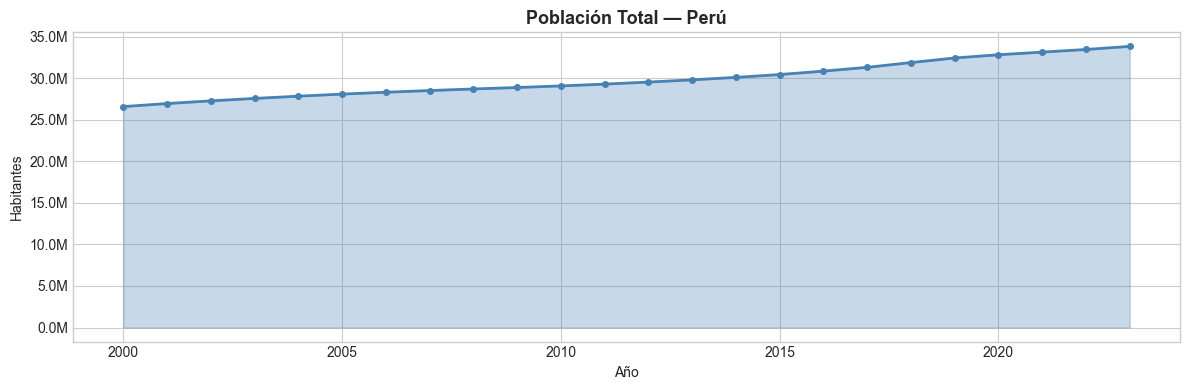

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(df_pop.index, df_pop["Poblacion_total"], alpha=0.3, color="steelblue")
df_pop["Poblacion_total"].plot(ax=ax, color="steelblue", linewidth=2, marker="o", markersize=4)
ax.set_title("Población Total — Perú", fontsize=13, fontweight="bold")
ax.set_ylabel("Habitantes")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000000:.1f}M"))
plt.tight_layout()
plt.show()

### 📥 Descarga — PIB y Población en América Latina

| Código | Indicador |
|---|---|
| `NY.GDP.MKTP.CD` | PIB (USD corrientes) |
| `SP.POP.TOTL` | Población total |

In [14]:
print('Países incluidos en LATAM:', LATAM)

Países incluidos en LATAM: ['ARG', 'BOL', 'BRA', 'CHL', 'COL', 'ECU', 'PRY', 'PER', 'URY', 'VEN', 'MEX', 'GTM', 'BLZ', 'SLV', 'HND', 'NIC', 'CRI', 'PAN', 'CUB', 'DOM', 'HTI']


In [15]:
df_wb = wb_fetch(
    paises     = LATAM,
    indicadores= ["NY.GDP.MKTP.CD", "SP.POP.TOTL"],
    año_inicio = 2000,
    año_fin    = 2024,
    nombres    = {"NY.GDP.MKTP.CD": "PIB", "SP.POP.TOTL": "Poblacion"}
)

df_wb.head(10)

✅ World Bank: 525 filas | 21 países | 2000 → 2024


,Pais,ISO3,Año,PIB,Poblacion
0,Argentina,ARG,2000,2.842038e+11,37213984.0
1,Argentina,ARG,2001,2.686968e+11,37624825.0
2,Argentina,ARG,2002,9.772400e+10,38029349.0
3,Argentina,ARG,2003,1.275870e+11,38424282.0
4,Argentina,ARG,2004,1.646579e+11,38815916.0
5,Argentina,ARG,2005,1.987371e+11,39216789.0
6,Argentina,ARG,2006,2.325573e+11,39622115.0
7,Argentina,ARG,2007,2.875305e+11,40016763.0
8,Argentina,ARG,2008,3.615580e+11,40424148.0
9,Argentina,ARG,2009,3.329765e+11,40854831.0


### 🔢 Calcular PIB per cápita

In [16]:
df_wb['PIB_per_capita'] = df_wb['PIB'] / df_wb['Poblacion']

###  Visualización — PIB per cápita en LATAM (2024)

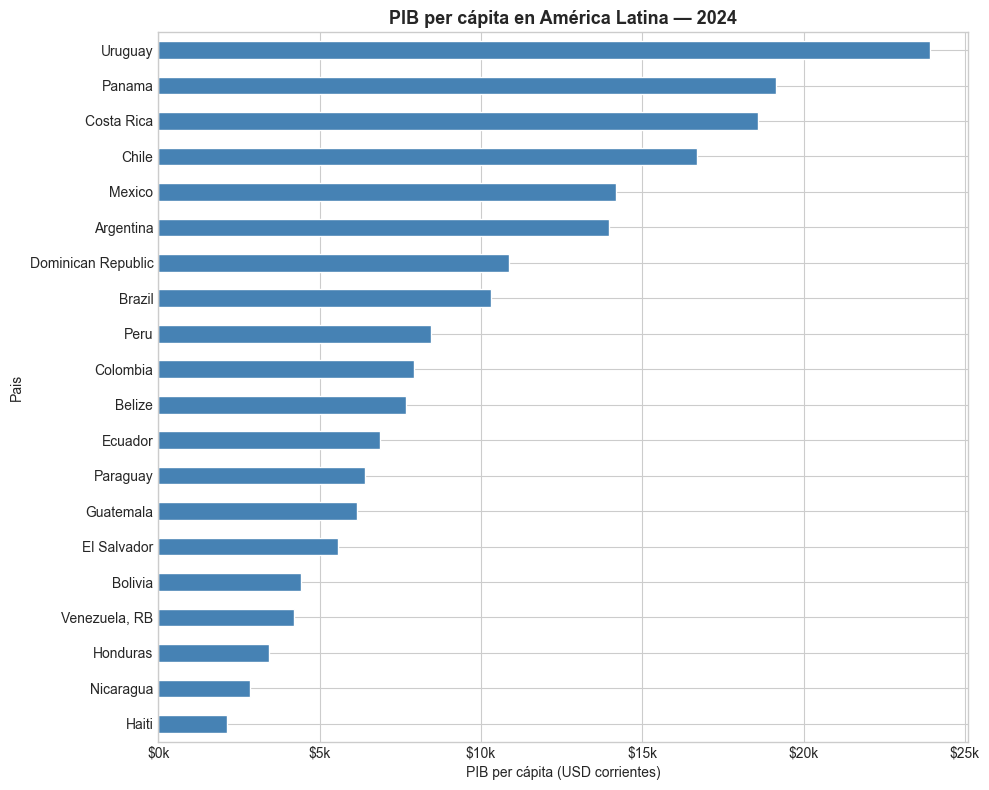

In [17]:
df_2024 = (
    df_wb[df_wb['Año'] == 2024][['Pais', 'PIB_per_capita']]
    .dropna()
    .set_index('Pais')
    .sort_values('PIB_per_capita')
)
fig, ax = plt.subplots(figsize=(10, 8))
df_2024.plot(kind='barh', ax=ax, legend=False, color='steelblue', edgecolor='white')

ax.set_title('PIB per cápita en América Latina — 2024', fontsize=13, fontweight='bold')
ax.set_xlabel('PIB per cápita (USD corrientes)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

###  Evolución del PIB per cápita — Países seleccionados (2000–2024)

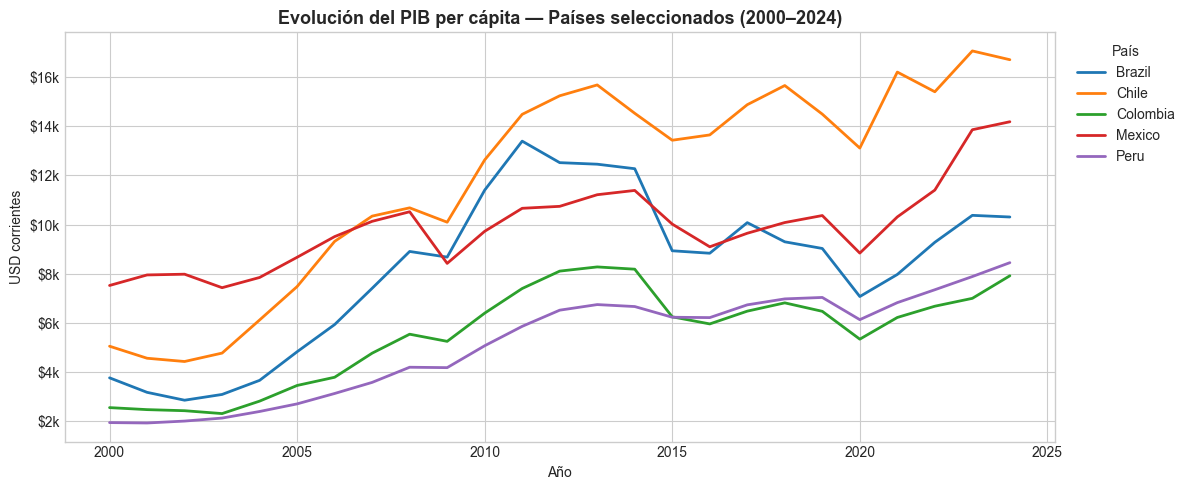

In [18]:
paises_sel = ['Peru', 'Chile', 'Colombia', 'Brazil', 'Mexico']

df_evol = (
    df_wb[df_wb['Pais'].isin(paises_sel)]
    .pivot(index='Año', columns='Pais', values='PIB_per_capita')
)

fig, ax = plt.subplots(figsize=(12, 5))
df_evol.plot(ax=ax, linewidth=2)

ax.set_title('Evolución del PIB per cápita — Países seleccionados (2000–2024)', fontsize=13, fontweight='bold')
ax.set_ylabel('USD corrientes')
ax.set_xlabel('Año')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend(title='País', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

##  Exportar los datos
Guarda los DataFrames para usarlos en tus modelos VAR.

In [19]:
df_ipc.to_csv('../data/bcrp_ipc.csv')
df_pbi.to_csv('../data/wb_pbi_peru.csv')
df_tc.to_csv('../data/bcrp_tipo_cambio.csv')
df_wb.to_csv('../data/wb_latam.csv', index=False)

print('✅ Datos exportados a la carpeta /data')

✅ Datos exportados a la carpeta /data
